<a href="https://colab.research.google.com/github/angie05huang/speed-dating-prediction-model/blob/main/SpeedDating_Prediction_Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install liac-arff pandas
import arff
from google.colab import files

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

In [ ]:
# DATA LOADING

# Upload the SpeedDating dataset as .arff file
# https://www.openml.org/search?type=data&id=40536&sort=runs&status=active
uploaded = files.upload()

Saving speeddating.arff to speeddating (1).arff


In [ ]:
# Load the dataset as dataframe and store .csv conversion
with open("speeddating.arff", "r") as f:
    arff_data = arff.load(f)

cols = [a[0] for a in arff_data['attributes']]
df = pd.DataFrame(arff_data['data'], columns=cols)

df.to_csv("speeddating.csv", index=False)

In [ ]:
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,decision,decision_o,match
0,0,1.0,female,21.0,27.0,6.0,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,0,0
1,0,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,1,0,0
2,1,1.0,female,21.0,22.0,1.0,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1,1,1
3,0,1.0,female,21.0,23.0,2.0,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1,1,1
4,0,1.0,female,21.0,24.0,3.0,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1,1,1


In [ ]:
# FEATURE ENGINEERING AND CLEANING

# Filter for only pairings with a female subject and male partner
df = df[df["gender"] == "male"]

# Filter for pairings that have not met before
df = df[df["met"] == 0].copy()

# Convert target variable to integer
df['match'] = df['match'].astype(int)

In [ ]:
core_categorical_cols = ['gender', 'race', 'race_o', 'field', 'has_null']

# Range features (all d_* columns that are strings/objects like '[3-5]')
d_nominal_cols = [col for col in df.columns if col.startswith('d_') and df[col].dtype == 'object']

print(f"Total number of core categorical nominal columns displayed: {len(core_categorical_cols)}")
print(f"Total number of d_* nominal columns displayed: {len(d_nominal_cols)}")

Total number of core categorical nominal columns displayed: 5
Total number of d_* nominal columns displayed: 55


In [ ]:
df_numeric = df.drop(columns=d_nominal_cols, errors='ignore')
df_cleaned = df_numeric.drop(columns=core_categorical_cols, errors='ignore')

Data Cleaning Summary
Total rows (after met=0 filter): 3835
Total columns used for correlation: 63

Correlation Analysis

Top 15 correlations with 'match':
                             match
sincere_partner           0.150849
intelligence_partner      0.156767
intelligence_o            0.167570
sinsere_o                 0.171277
shared_interests_partner  0.222906
guess_prob_liked          0.229833
funny_partner             0.241933
attractive_partner        0.248638
attractive_o              0.259756
shared_interests_o        0.280690
like                      0.281335
funny_o                   0.284903
decision                  0.451493
decision_o                0.574089
match                     1.000000


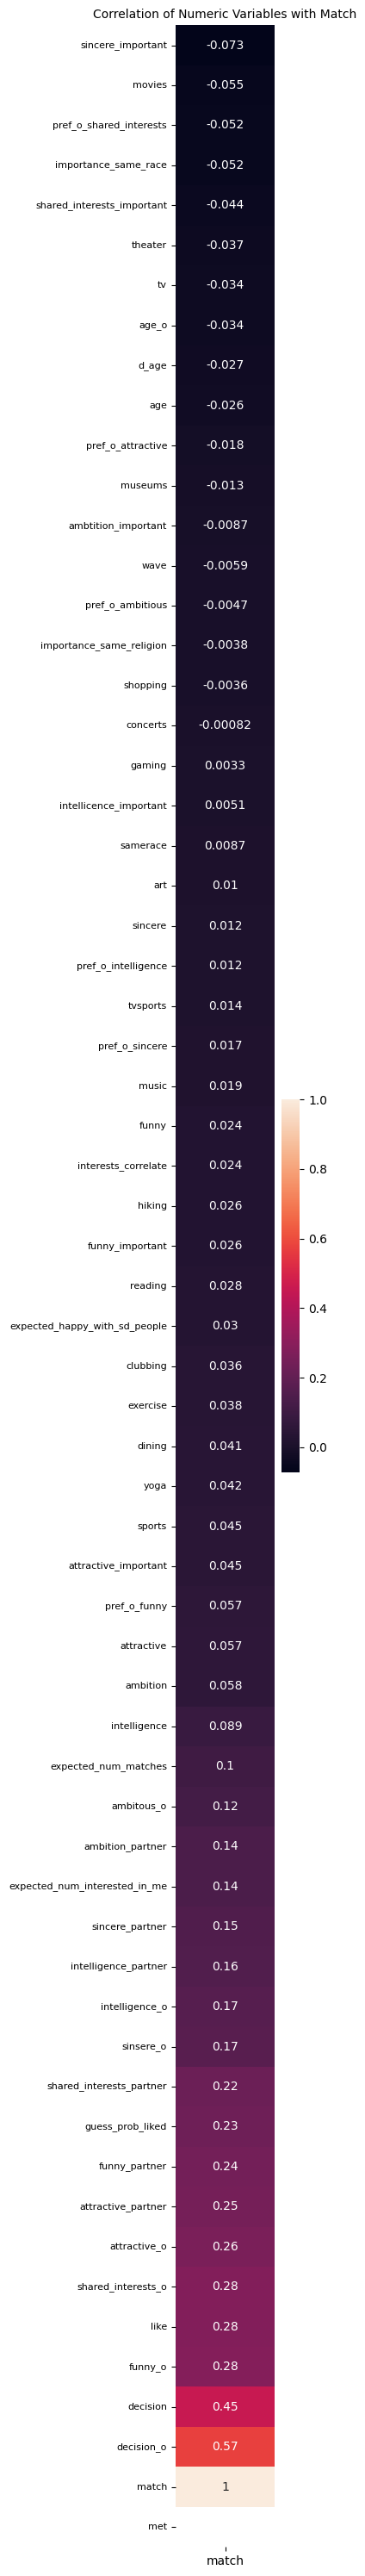

In [ ]:
# CORRELATION ANALYSIS

corr_with_match = df_cleaned.corr()[['match']].sort_values('match')

# Plot/save heatmap
plt.figure(figsize=(4, 30))
sns.heatmap(corr_with_match, annot=True)
plt.title('Correlation of Numeric Variables with Match', fontsize=10)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

print("Data Cleaning Summary")
print(f"Total rows (after met=0 filter): {len(df)}")
print(f"Total columns used for correlation: {len(df_cleaned.columns)}")

print("\nCorrelation Analysis")
print("\nTop 15 correlations with 'match':")
print(corr_with_match.tail(16).iloc[:-1])

In [ ]:
# Drop personality attribute columns that are highly correlated with match
personality_cols = [
    'attractive', 'sincere', 'intelligence', 'funny', 'ambition',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o'
]
df_no_personality = df_cleaned.drop(columns=personality_cols, errors='ignore')

# Remove highly correlated columns for true prediction
highly_correlated = ['like', 'decision', 'decision_o', 'shared_interests_partner', 'shared_interests_o']
df_final = df_no_personality.drop(columns=highly_correlated, errors='ignore')

df_final.head()

,wave,age,age_o,d_age,samerace,importance_same_race,importance_same_religion,pref_o_attractive,pref_o_sincere,pref_o_intelligence,...,music,shopping,yoga,interests_correlate,expected_happy_with_sd_people,expected_num_interested_in_me,expected_num_matches,guess_prob_liked,met,match
100,1.0,27.0,21.0,6.0,0,7.0,3.0,15.0,20.0,20.0,...,8.0,5.0,1.0,0.14,7.0,3.0,0.0,4.0,0.0,0
101,1.0,27.0,24.0,3.0,1,7.0,3.0,45.0,5.0,25.0,...,8.0,5.0,1.0,0.29,7.0,3.0,0.0,2.0,0.0,0
103,1.0,27.0,23.0,4.0,1,7.0,3.0,20.0,20.0,20.0,...,8.0,5.0,1.0,-0.18,7.0,3.0,0.0,3.0,0.0,0
104,1.0,27.0,21.0,6.0,1,7.0,3.0,20.0,5.0,25.0,...,8.0,5.0,1.0,-0.43,7.0,3.0,0.0,5.0,0.0,0
105,1.0,27.0,23.0,4.0,0,7.0,3.0,10.0,25.0,20.0,...,8.0,5.0,1.0,0.33,7.0,3.0,0.0,4.0,0.0,0


In [ ]:
# RANDOM FOREST MODEL TRAINING AND EVALUATION

X = df_final.drop('match', axis=1)
y = df_final['match']

# Split train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

In [ ]:
# Grid Search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 4, 8],
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
)

grid_rf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 4, 8],
                         'n_estimators': [50, 100, 150]},
             scoring='roc_auc')

In [ ]:
# Get Best Model and Predict
best_rf_model = grid_rf.best_estimator_
y_pred = best_rf_model.predict(X_test)
y_proba = best_rf_model.predict_proba(X_test)[:, 1]

print("\nGrid Search Tuning Results")
print("Best hyperparameters:", grid_rf.best_params_)
print(f"Best Cross-Validation AUC-ROC Score: {grid_rf.best_score_}")

print("\nFinal Model Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

top_features = pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

print("\nTop 10 Features:")
print(top_features)


Grid Search Tuning Results
Best hyperparameters: {'max_depth': 8, 'n_estimators': 150}
Best Cross-Validation AUC-ROC Score: 0.7597775609388184

Final Model Evaluation
Accuracy: 0.8477580813347236

Classification Report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       809
           1       0.83      0.03      0.06       150

    accuracy                           0.85       959
   macro avg       0.84      0.52      0.49       959
weighted avg       0.85      0.85      0.78       959


Top 10 Features:
attractive_partner         0.073601
funny_partner              0.066362
guess_prob_liked           0.063703
interests_correlate        0.040435
age_o                      0.032626
expected_num_matches       0.030842
pref_o_attractive          0.028260
intelligence_partner       0.027888
pref_o_intelligence        0.026866
pref_o_shared_interests    0.025757
dtype: float64
